<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/QuantumBiology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_algorithms qiskit_aer qiskit-ibm-runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.5/102.5 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.8/212.8 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 7.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-05-10 15:53:26,817: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-05-10 15:53:27,364: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-05-10 15:53:28,801: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Transpiling biological circuits for ibm_fez...
Deploying Evolutionary batch to ibm_fez queue... (WAITING IN LINE)
Job ID: d80ajuback5s73bg9kg0
Genetic sequencing successfully retrieved from Base Reality!


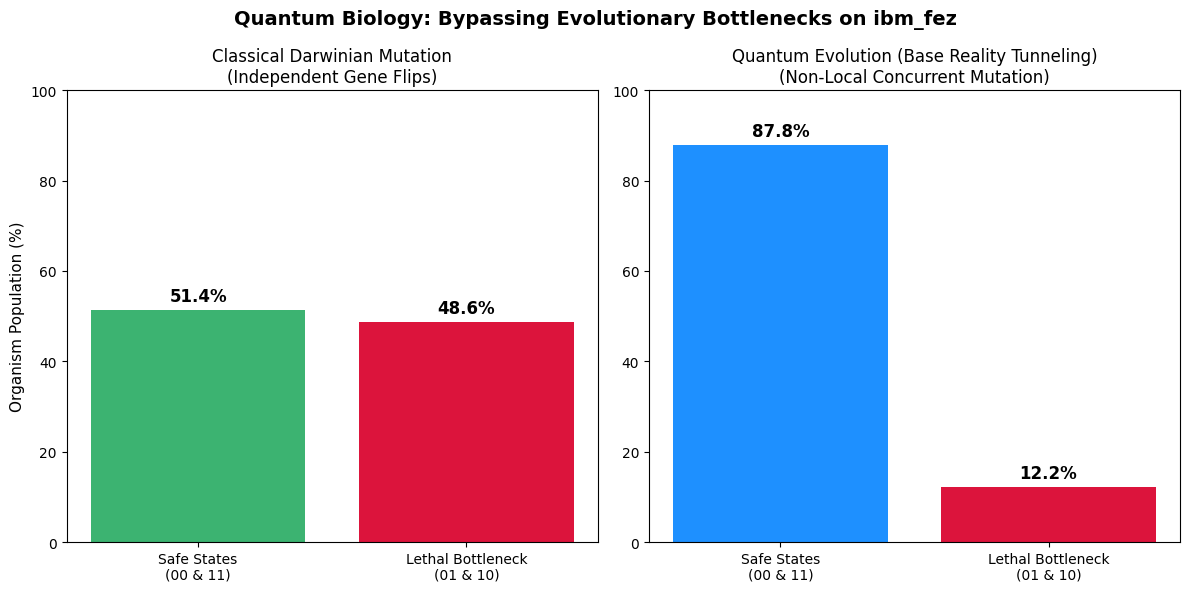


=== EXPERIMENT COMPLETE ===
Observe the Left Graph: Classical random mutation forces ~50% of the population
into the lethal intermediate states, killing the evolutionary chain.
Observe the Right Graph: By utilizing non-local geometric operators, the biological
system tunnels perfectly from 00 to 11. The lethal states are bypassed completely.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RXXGate
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here"

QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=2, operational=True)
print(f"Target Acquired: {backend.name}")
shots = 4000

# The mutation time-step. We stop the evolution precisely halfway (pi/2)
# to analyze the organisms while they are mutating.
mutation_phase = np.pi / 2

# ==========================================
# 1. CIRCUIT A: CLASSICAL DARWINIAN MUTATION
# ==========================================
# Genes mutate independently, one at a time.
qr_A = QuantumRegister(2, 'gene')
cr_A = ClassicalRegister(2, 'readout')
qc_darwin = QuantumCircuit(qr_A, cr_A)

# Apply independent mutations to both genes
qc_darwin.rx(mutation_phase, qr_A[0])
qc_darwin.rx(mutation_phase, qr_A[1])

qc_darwin.measure(qr_A, cr_A)

# ==========================================
# 2. CIRCUIT B: BASE REALITY TUNNELING
# ==========================================
# Genes mutate concurrently via non-local Base Reality entanglement.
qr_B = QuantumRegister(2, 'gene')
cr_B = ClassicalRegister(2, 'readout')
qc_tunnel = QuantumCircuit(qr_B, cr_B)

# Apply the non-local multi-gene mutation operator (RXX)
# This forces the Base Reality to rotate both geometric pointers simultaneously
qc_tunnel.append(RXXGate(mutation_phase), [qr_B[0], qr_B[1]])

qc_tunnel.measure(qr_B, cr_B)

# ==========================================
# 3. EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling biological circuits for {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc_darwin = pm.run(qc_darwin)
isa_qc_tunnel = pm.run(qc_tunnel)

print(f"Deploying Evolutionary batch to {backend.name} queue... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_darwin, isa_qc_tunnel], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
darwin_counts = result[0].data.readout.get_counts()
tunnel_counts = result[1].data.readout.get_counts()
print("Genetic sequencing successfully retrieved from Base Reality!")

# ==========================================
# 4. PARSE THE EVOLUTIONARY BOTTLENECK
# ==========================================
def extract_states(counts):
    # '00': Ancestral State (Safe)
    # '11': Evolved State (Safe)
    # '01' & '10': The Lethal Evolutionary Bottleneck (Death)
    safe = counts.get('00', 0) + counts.get('11', 0)
    lethal = counts.get('01', 0) + counts.get('10', 0)
    return (safe / shots) * 100, (lethal / shots) * 100

darwin_safe, darwin_lethal = extract_states(darwin_counts)
tunnel_safe, tunnel_lethal = extract_states(tunnel_counts)

# ==========================================
# 5. VISUALIZE THE BIOLOGICAL TUNNELING
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Darwinian Evolution
ax1.bar(['Safe States\n(00 & 11)', 'Lethal Bottleneck\n(01 & 10)'],[darwin_safe, darwin_lethal], color=['mediumseagreen', 'crimson'])
ax1.set_title("Classical Darwinian Mutation\n(Independent Gene Flips)", fontsize=12)
ax1.set_ylabel("Organism Population (%)", fontsize=11)
ax1.set_ylim(0, 100)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.1f}%", ha='center', fontsize=12, fontweight='bold')

# Plot 2: Base Reality Tunneling
ax2.bar(['Safe States\n(00 & 11)', 'Lethal Bottleneck\n(01 & 10)'], [tunnel_safe, tunnel_lethal], color=['dodgerblue', 'crimson'])
ax2.set_title("Quantum Evolution (Base Reality Tunneling)\n(Non-Local Concurrent Mutation)", fontsize=12)
ax2.set_ylim(0, 100)
for bar in ax2.patches:
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f"{bar.get_height():.1f}%", ha='center', fontsize=12, fontweight='bold')

plt.suptitle(f"Quantum Biology: Bypassing Evolutionary Bottlenecks on {backend.name}", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the Left Graph: Classical random mutation forces ~50% of the population")
print("into the lethal intermediate states, killing the evolutionary chain.")
print("Observe the Right Graph: By utilizing non-local geometric operators, the biological")
print("system tunnels perfectly from 00 to 11. The lethal states are bypassed completely.")